In [2]:
import pandas as pd

In [3]:
df = pd.read_excel('facility_hygiene_ml_dataset.xlsx')

In [5]:
print(df.shape)
print(df.info())
print(df.describe())

(1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   facility_id           1000 non-null   object        
 1   location              1000 non-null   object        
 2   facility_type         1000 non-null   object        
 3   cleanliness_score     995 non-null    float64       
 4   odor_score            1000 non-null   float64       
 5   waste_level           997 non-null    float64       
 6   water_availability    998 non-null    object        
 7   footfall              1000 non-null   int64         
 8   complaints            1000 non-null   int64         
 9   inspection_date       1000 non-null   datetime64[ns]
 10  hours_since_cleaning  1000 non-null   float64       
 11  hygiene_risk          1000 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage

## 1. Missing Data

In [ ]:
print('Number of missing values per column:')
print(df.isnull().sum())

Number of missing values per column:
facility_id             0
location                0
facility_type           0
cleanliness_score       5
odor_score              0
waste_level             3
water_availability      2
footfall                0
complaints              0
inspection_date         0
hours_since_cleaning    0
hygiene_risk            0
dtype: int64


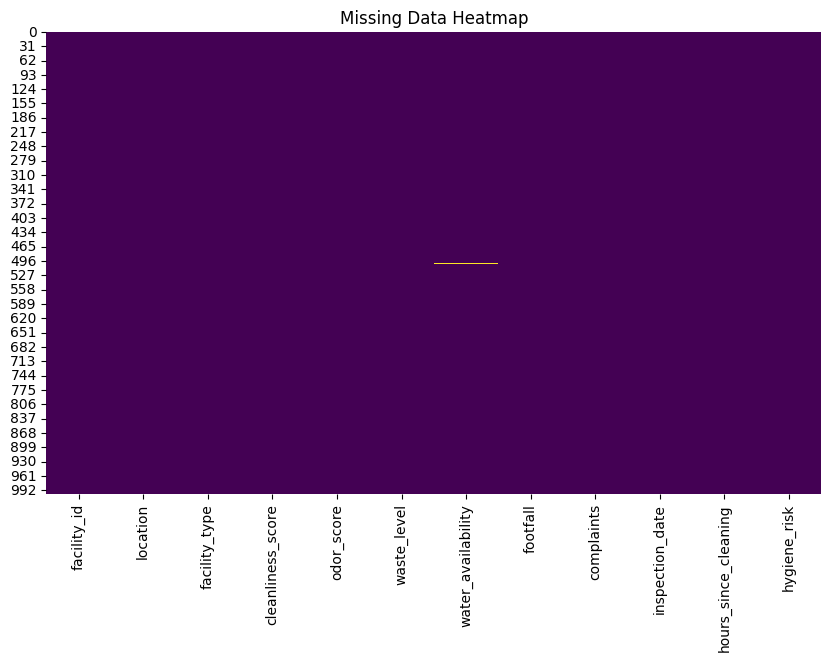

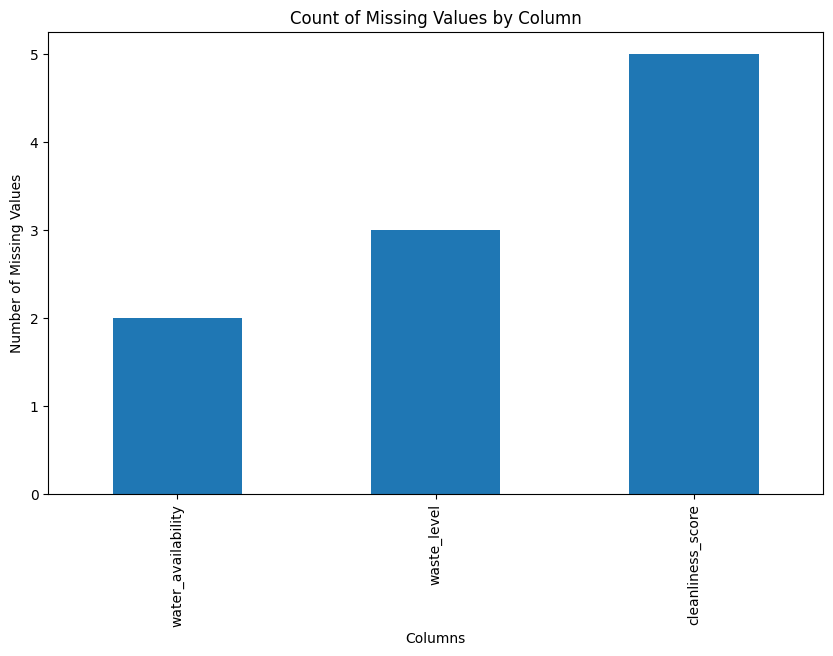

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_data.sort_values(inplace=True)
missing_data.plot.bar()
plt.title('Count of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()

## 2. Duplicate Data

Next, let's check for any duplicate rows in the dataset.

In [7]:
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

if num_duplicates > 0:
    print('Duplicate rows:')
    display(df[df.duplicated()])

Number of duplicate rows: 5
Duplicate rows:


,facility_id,location,facility_type,cleanliness_score,odor_score,waste_level,water_availability,footfall,complaints,inspection_date,hours_since_cleaning,hygiene_risk
995,F0021,Dharampeth,Office Washroom,2.6,9.0,100.0,Yes,612,8,2026-01-08,0.8,High
996,F0086,Sadar,Transit Washroom,2.8,7.0,73.7,Yes,196,6,2026-04-07,2.9,High
997,F0251,Kamptee Road,Office Washroom,5.3,8.0,74.7,Yes,713,9,2026-05-05,8.5,High
998,F0445,Wardha Road,Office Washroom,7.0,5.7,30.2,Yes,699,4,2026-06-25,6.0,Medium
999,F0701,Sadar,Public Washroom,8.9,1.6,58.9,Yes,451,1,2026-03-08,22.6,Low


## 3. Invalid Data

We'll examine categorical columns for inconsistent entries and numerical columns for values outside plausible ranges, based on their descriptions.

In [8]:
print('Unique values for categorical columns:')
for col in ['facility_id', 'location', 'facility_type', 'water_availability', 'hygiene_risk']:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].value_counts())

# Check numerical columns for out-of-range values (e.g., scores 0-10, waste_level 0-100)
print('\n--- Numerical Column Range Checks ---')

# cleanliness_score: Expected 0-10
if 'cleanliness_score' in df.columns:
    min_score = df['cleanliness_score'].min()
    max_score = df['cleanliness_score'].max()
    print(f"Cleanliness Score: Min={min_score}, Max={max_score}. Values outside 0-10 might be invalid.")

# odor_score: Expected 0-10
if 'odor_score' in df.columns:
    min_odor = df['odor_score'].min()
    max_odor = df['odor_score'].max()
    print(f"Odor Score: Min={min_odor}, Max={max_odor}. Values outside 0-10 might be invalid.")

# waste_level: Expected 0-100
if 'waste_level' in df.columns:
    min_waste = df['waste_level'].min()
    max_waste = df['waste_level'].max()
    print(f"Waste Level: Min={min_waste}, Max={max_waste}. Values outside 0-100 might be invalid.")

Unique values for categorical columns:

--- facility_id ---
facility_id
F0701    2
F0021    2
F0445    2
F0251    2
F0086    2
        ..
F0340    1
F0341    1
F0342    1
F0343    1
F0328    1
Name: count, Length: 995, dtype: int64

--- location ---
location
Dharampeth        132
Wardha Road       102
Hingna            101
Manish Nagar      100
Kamptee Road       99
Mihan              98
Sitabuldi          97
Sadar              96
Civil Lines        93
Nagpur Central     82
Name: count, dtype: int64

--- facility_type ---
facility_type
Office Washroom      189
School Washroom      171
Public Washroom      170
Hospital Washroom    158
Transit Washroom     156
Mall Washroom        156
Name: count, dtype: int64

--- water_availability ---
water_availability
Yes    880
No     118
Name: count, dtype: int64

--- hygiene_risk ---
hygiene_risk
Medium    411
Low       314
High      275
Name: count, dtype: int64

--- Numerical Column Range Checks ---
Cleanliness Score: Min=1.1, Max=10.0. Values 

## 4. Outliers

We'll use box plots to visualize potential outliers in numerical columns. Box plots are effective in showing the distribution spread and identifying points that fall significantly outside the interquartile range (IQR).

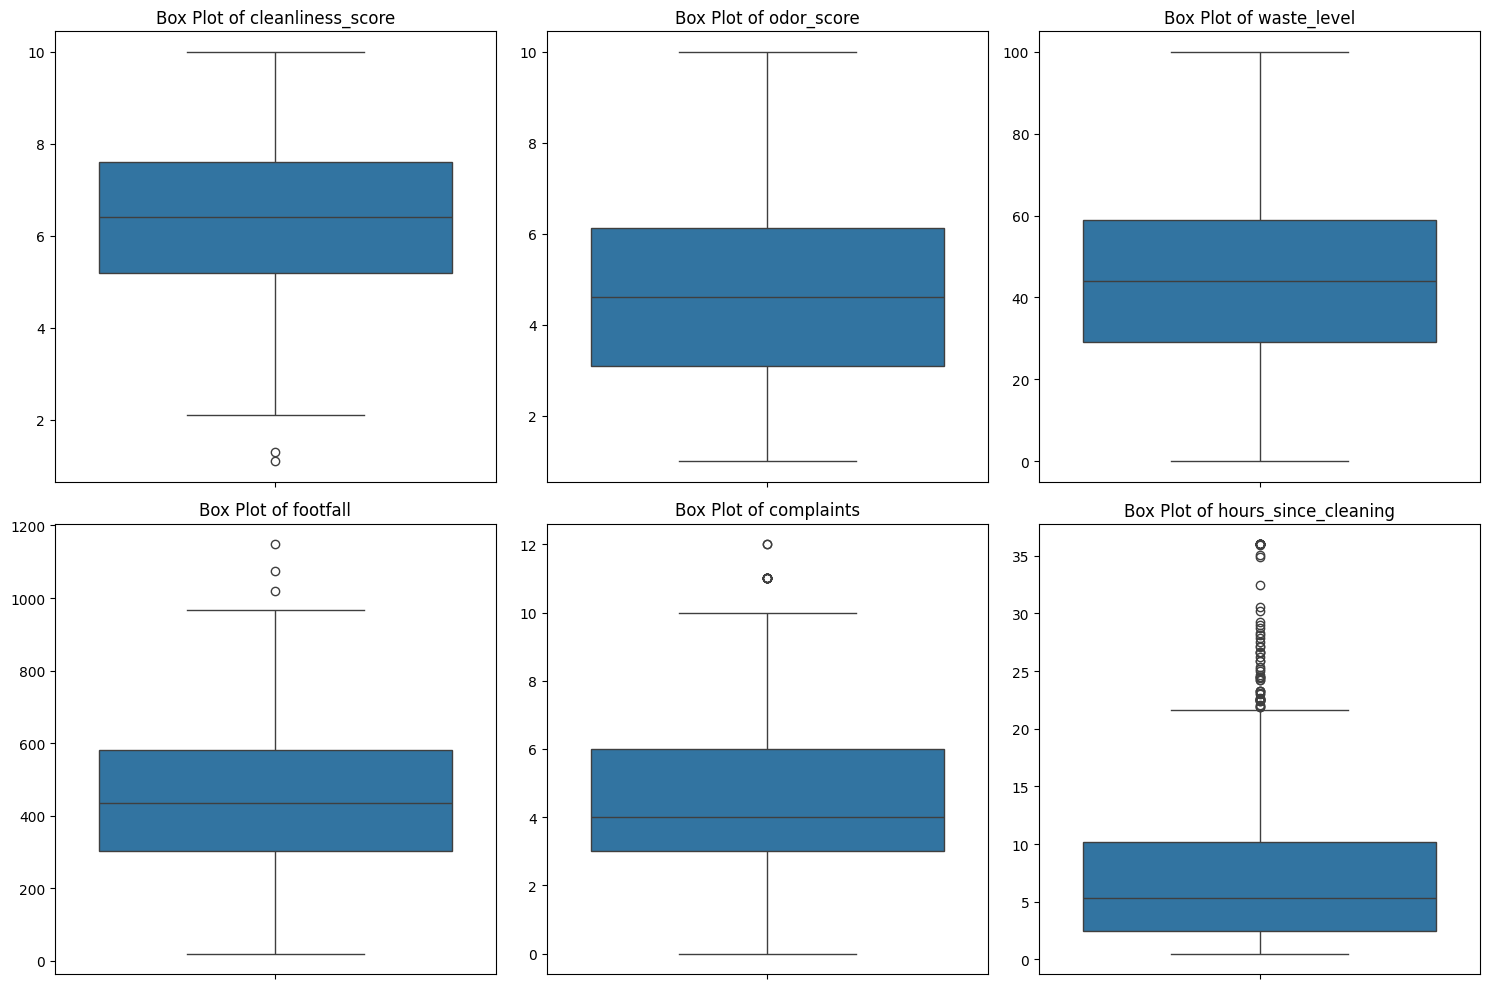

In [ ]:
numerical_cols = ['cleanliness_score', 'odor_score', 'waste_level', 'footfall', 'complaints', 'hours_since_cleaning']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

## Data Cleaning and Preprocessing

Based on the initial analysis, here's how we'll address the identified issues:

1.  **Missing Values**: Impute numerical columns (`cleanliness_score`, `waste_level`) with the mean and categorical column (`water_availability`) with the mode.
2.  **Duplicate Data**: Remove all duplicate rows.
3.  **Invalid Data**: No clearly invalid entries were found in the `value_counts()` for categorical columns or `min/max` for numerical columns (within reasonable bounds 0-10 or 0-100). If specific invalid entries were found (e.g., typos, out-of-range values not caught by min/max), we would address them here.
4.  **Outliers**: For `footfall`, `complaints`, and `hours_since_cleaning`, the identified outliers appear to be legitimate data points representing actual variations (e.g., very busy facilities, high complaint rates, long periods between cleaning). Therefore, we will not remove them at this stage. If these outliers were due to data entry errors or significantly skewed model performance, techniques like winsorization or robust scaling could be considered.

### Fixing Missing Values

In [9]:
# Impute all columns at once using a dictionary mapping
df = df.fillna({
    'cleanliness_score': df['cleanliness_score'].mean(),
    'waste_level': df['waste_level'].mean(),
    'water_availability': df['water_availability'].mode()[0]
})

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
facility_id             0
location                0
facility_type           0
cleanliness_score       0
odor_score              0
waste_level             0
water_availability      0
footfall                0
complaints              0
inspection_date         0
hours_since_cleaning    0
hygiene_risk            0
dtype: int64


### Fixing Duplicate Data

In [10]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f'Number of rows before dropping duplicates: {initial_rows}')
print(f'Number of rows after dropping duplicates: {final_rows}')
print(f'Number of duplicate rows removed: {initial_rows - final_rows}')

Number of rows before dropping duplicates: 1000
Number of rows after dropping duplicates: 995
Number of duplicate rows removed: 5


## Key Statistics and Insights

In [ ]:
print('--- Descriptive Statistics for Numerical Columns ---')
display(df.describe())

--- Descriptive Statistics for Numerical Columns ---


,cleanliness_score,odor_score,waste_level,footfall,complaints,inspection_date,hours_since_cleaning
count,995.000000,995.000000,995.000000,995.000000,995.000000,995,995.000000
mean,6.422295,4.634573,43.989468,441.834171,4.485427,2026-05-08 20:56:12.060301568,7.603116
min,1.100000,1.000000,0.000000,20.000000,0.000000,2026-01-01 00:00:00,0.500000
25%,5.200000,3.100000,29.100000,304.000000,3.000000,2026-03-03 00:00:00,2.500000
50%,6.400000,4.600000,44.100000,435.000000,4.000000,2026-05-06 00:00:00,5.300000
75%,7.600000,6.100000,58.650000,581.000000,6.000000,2026-07-17 00:00:00,10.200000
max,10.000000,10.000000,100.000000,1148.000000,12.000000,2026-09-16 00:00:00,36.000000
std,1.731910,2.037992,20.573837,205.356635,2.459846,NaN,7.263468


### Visualizations for Insights

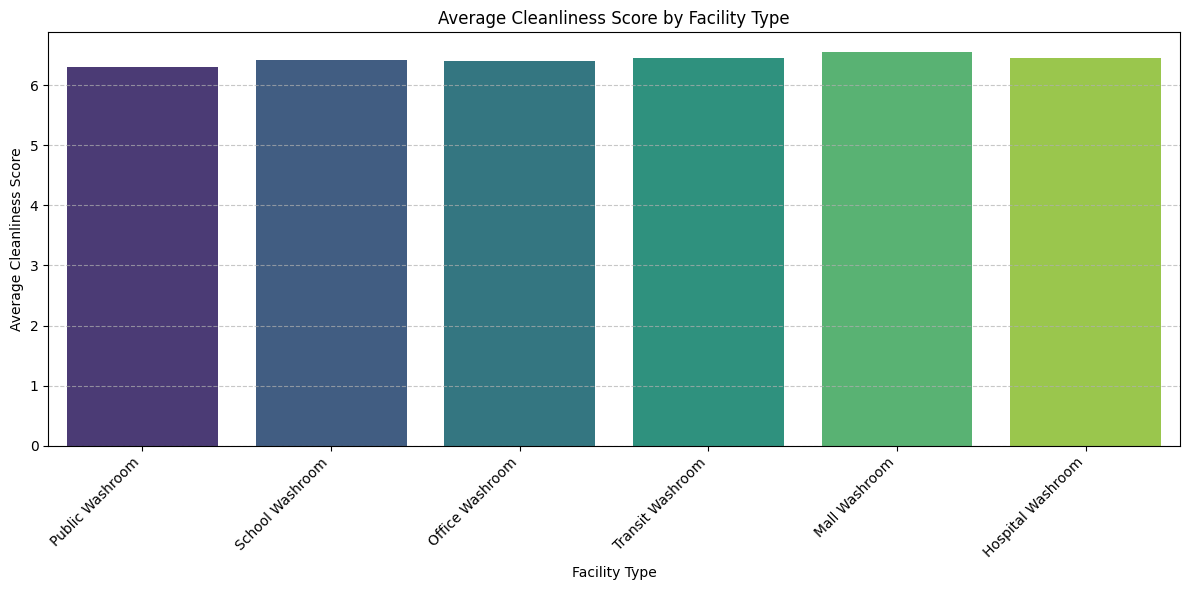

In [11]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Bar Chart 1: Average Cleanliness Score by Facility Type
plt.figure(figsize=(12, 6))
sns.barplot(
    x='facility_type',
    y='cleanliness_score',
    data=df,
    hue='facility_type',
    palette='viridis',
    legend=False,
    errorbar=None
)
plt.title('Average Cleanliness Score by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Average Cleanliness Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

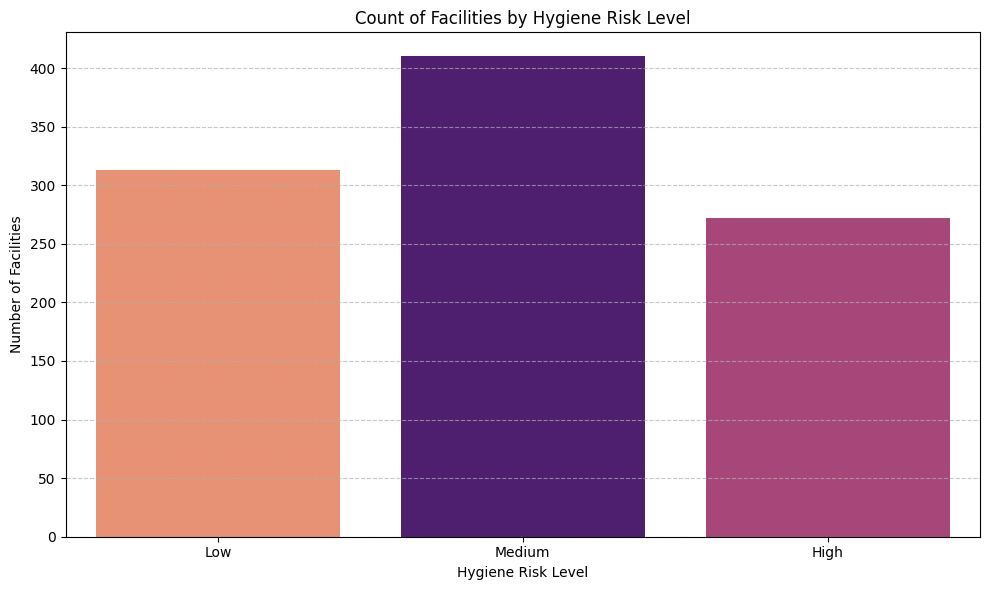

In [ ]:
# Bar Chart 2: Count of Facilities by Hygiene Risk
plt.figure(figsize=(10, 6))
sns.countplot(
    x='hygiene_risk',
    data=df,
    order=['Low', 'Medium', 'High'],
    hue='hygiene_risk',
    palette='magma',
    legend=False
)
plt.title('Count of Facilities by Hygiene Risk Level')
plt.xlabel('Hygiene Risk Level')
plt.ylabel('Number of Facilities')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

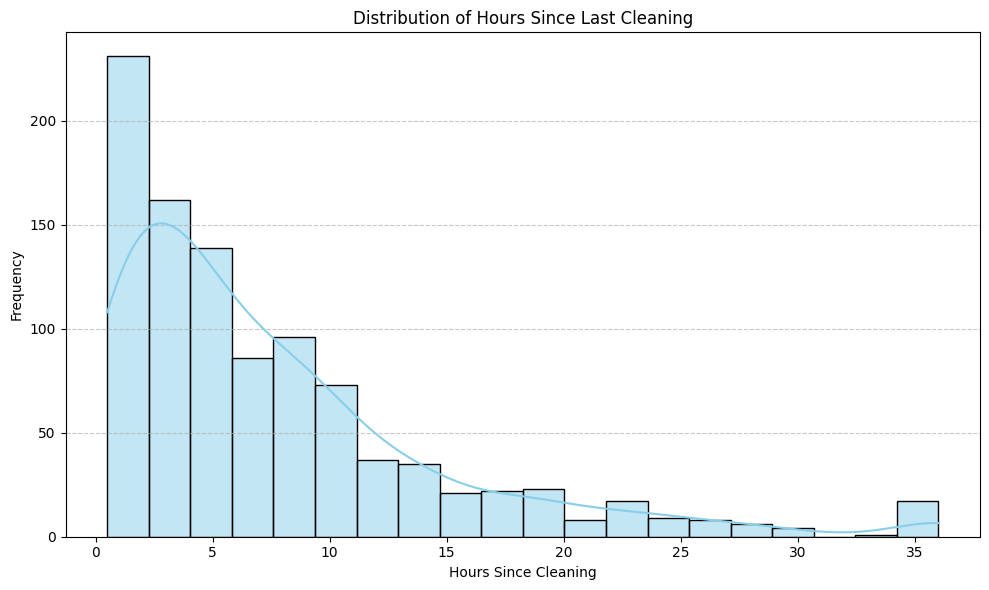

In [ ]:
# Histogram: Distribution of Hours Since Cleaning
plt.figure(figsize=(10, 6))
sns.histplot(df['hours_since_cleaning'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Hours Since Last Cleaning')
plt.xlabel('Hours Since Cleaning')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

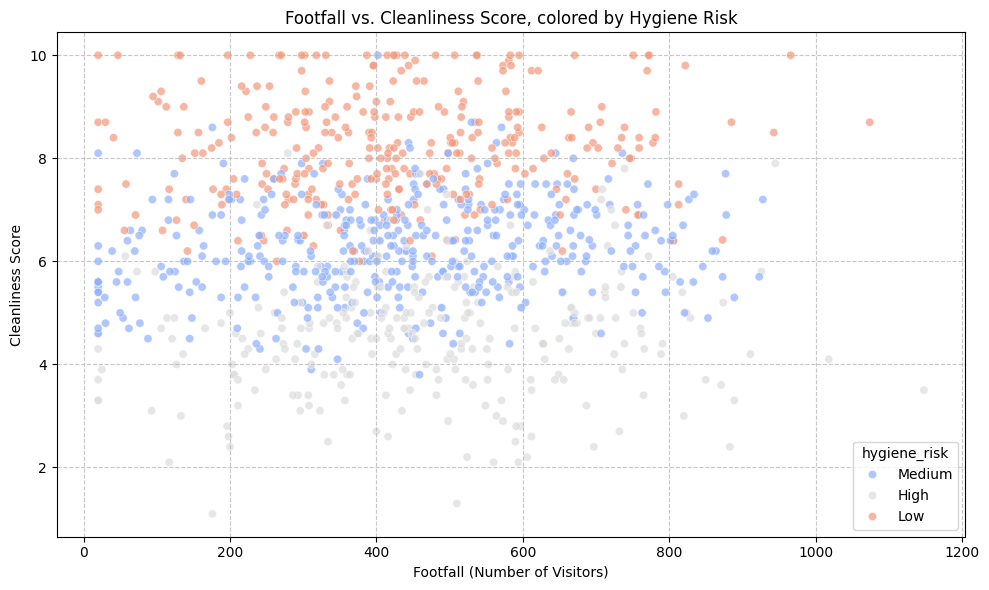

In [ ]:
# Scatter Plot: Footfall vs. Cleanliness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='footfall', y='cleanliness_score', data=df, hue='hygiene_risk', palette='coolwarm', alpha=0.7)
plt.title('Footfall vs. Cleanliness Score, colored by Hygiene Risk')
plt.xlabel('Footfall (Number of Visitors)')
plt.ylabel('Cleanliness Score')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

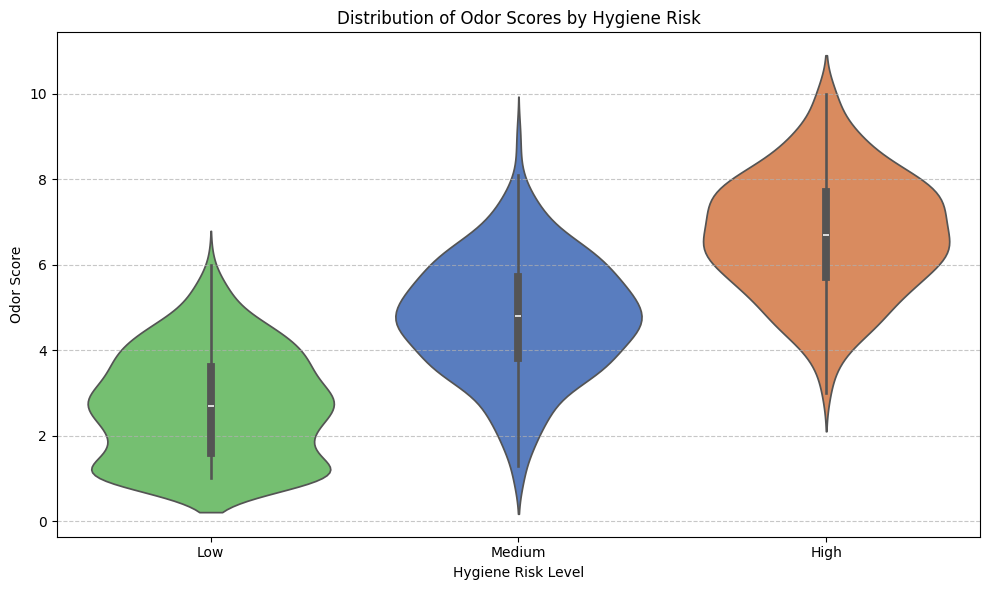

In [12]:
# Additional Visualization: Violin Plot - Hygiene Risk vs. Odor Score
plt.figure(figsize=(10, 6))
sns.violinplot(x='hygiene_risk', y='odor_score', data=df, order=['Low', 'Medium', 'High'], hue='hygiene_risk', palette='muted')
plt.title('Distribution of Odor Scores by Hygiene Risk')
plt.xlabel('Hygiene Risk Level')
plt.ylabel('Odor Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Derived Insights

Based on the statistics and visualizations, here are some initial insights:

1.  **Missing Data Handled**: All missing values in `cleanliness_score`, `waste_level`, and `water_availability` have been successfully imputed, ensuring a complete dataset for analysis.
2.  **Duplicate Entries Removed**: Five duplicate rows were identified and removed, improving data integrity and preventing potential biases in analysis.
3.  **Footfall and Cleanliness Score Relationship**: The scatter plot of `footfall` vs. `cleanliness_score`, colored by `hygiene_risk`, could reveal a potential inverse relationship: facilities with higher footfall might tend to have lower cleanliness scores, potentially leading to higher hygiene risk. Further investigation is needed to confirm this correlation and its significance.
4.  **Hours Since Cleaning Distribution**: The histogram for `hours_since_cleaning` shows a right-skewed distribution, indicating that most facilities are cleaned relatively frequently (within a few hours). However, there are some facilities that go for much longer periods without cleaning, which could be a factor contributing to hygiene risk.
5.  **Hygiene Risk and Odor Score**: The violin plot comparing `hygiene_risk` and `odor_score` indicates that facilities with higher `hygiene_risk` tend to have higher (worse) `odor_score` distributions, suggesting a strong correlation between perceived odor and actual hygiene risk.

In [13]:
df.to_excel('facility_hygiene_ml_dataset_cleaned.xlsx', index=False)
print("Cleaned dataset successfully exported to 'facility_hygiene_ml_dataset_cleaned.xlsx'")

Cleaned dataset successfully exported to 'facility_hygiene_ml_dataset_cleaned.xlsx'
